## Wearable Tech: Week 2 Assignment

### Step 1

In [10]:
# imports
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime

#turns off warning for chained assignment as we are overwriting references to original dataframe
pd.options.mode.chained_assignment = None  # default='warn'
pd.set_option('display.max_rows', 30)

df = pd.read_csv("../Data/Soccer.csv", parse_dates=["Date"])

### Step 2

In [11]:
session_df = df.loc[df['Period.Name'] == "Session"]

session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06
1,89,Session,GK,238.00543,14.04880,205,101,174.15563,2019-08-06
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06
...,...,...,...,...,...,...,...,...,...
9499,23,Session,GK,185.24280,4.66020,0,0,0.00000,2019-11-24
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24


### Step 3

In [12]:
session_df['Session.Duration'] = session_df['Total.Player.Load']/session_df['Player.Load.Per.Minute']
session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date,Session.Duration
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06,18.054328
1,89,Session,GK,238.00543,14.04880,205,101,174.15563,2019-08-06,16.941335
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06,16.143162
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06,18.900662
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06,18.310667
...,...,...,...,...,...,...,...,...,...,...
9499,23,Session,GK,185.24280,4.66020,0,0,0.00000,2019-11-24,39.749968
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24,138.183361
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24,115.050023
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24,91.195626


### Step 4

In [13]:
Rank_Total_PL = session_df.groupby(['Player.Name', 'Position.Name'])[['Total.Player.Load']].sum()
print("Total Training Load captured for entire season")


print(Rank_Total_PL.sort_values(by='Total.Player.Load', ascending = False))

Total Training Load captured for entire season
                           Total.Player.Load
Player.Name Position.Name                   
43          M                    61807.06587
62          F                    55455.84319
4           M                    54531.06541
21          D                    52448.84502
44          D                    45528.61318
66          M                    44035.16557
100         D                    43435.17877
39          D                    42966.83272
12          D                    42594.47149
52          D                    41966.27363
35          F                    39743.46043
86          M                    38332.92067
10          D                    35760.14918
63          F                    34497.65386
15          D                    32792.41598
18          D                    28582.29879
97          F                    28388.64588
49          F                    28331.33281
91          F                    27545.34959
48      

### Step 5

In [14]:
session_df.sort_values(by='Total.Player.Load', ascending = False).head(10)

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date,Session.Duration
8482,43,Session,M,1755.08710,11.85336,218,0,162.17158,2019-11-08,148.066633
9338,43,Session,M,1701.65860,12.84722,229,0,168.91000,2019-11-22,132.453449
4874,62,Session,F,1695.69403,12.77450,210,0,147.47929,2019-09-19,132.740540
4883,43,Session,M,1672.69440,13.69880,217,0,165.77741,2019-09-19,122.105177
4489,43,Session,M,1649.17551,11.38274,219,0,164.28843,2019-09-13,144.883878
5697,4,Session,M,1641.06146,10.75199,205,94,170.58953,2019-09-29,152.628626
3536,43,Session,M,1635.75719,9.69604,210,0,150.83079,2019-09-01,168.703635
5703,43,Session,M,1617.42587,11.99220,225,0,166.82273,2019-09-29,134.873157
8471,62,Session,F,1576.30459,10.64591,215,0,159.91105,2019-11-08,148.066684
5937,4,Session,M,1565.28558,9.92887,199,0,162.30780,2019-10-03,157.649922


In [ ]:
all 10

### Step 6

In [15]:
numbers_to_drop = [98, 62, 89, 23, 71]
session_df = session_df[~session_df['Player.Name'].isin(numbers_to_drop)]
session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date,Session.Duration
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06,18.054328
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06,16.143162
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06,18.900662
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06,18.310667
5,35,Session,F,315.51553,16.69335,0,0,0.00000,2019-08-06,18.900672
...,...,...,...,...,...,...,...,...,...,...
9498,100,Session,D,1161.67722,9.04267,127,0,127.00000,2019-11-24,128.466174
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24,138.183361
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24,115.050023
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24,91.195626


In [16]:
session_df['Player.Name'] = session_df['Player.Name'].astype('object')
session_df 

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date,Session.Duration
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06,18.054328
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06,16.143162
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06,18.900662
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06,18.310667
5,35,Session,F,315.51553,16.69335,0,0,0.00000,2019-08-06,18.900672
...,...,...,...,...,...,...,...,...,...,...
9498,100,Session,D,1161.67722,9.04267,127,0,127.00000,2019-11-24,128.466174
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24,138.183361
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24,115.050023
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24,91.195626


### Step 7 

In [23]:
session_df=session_df.reset_index()
session_df.head()

,level_0,Date,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration
0,0,2019-08-06,12,Session,D,276.85373,15.33448,205,0,170.91685,18.054328
1,1,2019-08-06,63,Session,F,231.84551,14.36184,206,0,179.25900,16.143162
2,2,2019-08-06,15,Session,D,355.02606,18.78379,216,0,177.66543,18.900662
3,3,2019-08-06,44,Session,D,318.82076,17.41175,218,0,180.77740,18.310667
4,4,2019-08-06,35,Session,F,315.51553,16.69335,0,0,0.00000,18.900672


In [24]:
session_df = session_df.drop(columns=['level_0'], errors='ignore')

In [25]:
session_df=session_df.set_index('Date')
session_df.head()

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration
Date,,,,,,,,,
2019-08-06,12,Session,D,276.85373,15.33448,205,0,170.91685,18.054328
2019-08-06,63,Session,F,231.84551,14.36184,206,0,179.25900,16.143162
2019-08-06,15,Session,D,355.02606,18.78379,216,0,177.66543,18.900662
2019-08-06,44,Session,D,318.82076,17.41175,218,0,180.77740,18.310667
2019-08-06,35,Session,F,315.51553,16.69335,0,0,0.00000,18.900672


In [27]:
df_43 = session_df.loc[session_df['Player.Name'] == 43] 
df_43 = df_43.resample('D').sum()
df_43 = df_43.fillna(0)
df_43

,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration
Date,,,,,,
2019-08-06,1384.29407,35.61502,624,0,481.55868,148.599858
2019-08-07,1231.07260,12.98502,399,0,289.58705,192.827240
2019-08-08,0.00000,0.00000,0,0,0.00000,0.000000
2019-08-09,1258.91826,15.41278,406,0,297.78315,163.980353
2019-08-10,614.87480,7.13326,219,0,132.28724,86.198288
...,...,...,...,...,...,...
2019-11-20,323.13271,6.67317,203,0,134.71798,48.422670
2019-11-21,329.35446,6.99762,80,80,80.00000,47.066640
2019-11-22,1701.65860,12.84722,229,0,168.91000,132.453449


In [28]:
df_43["Acute_PL"] = (df_43.loc[:,"Total.Player.Load"].rolling('3D', 3).sum())/3
df_43["Chronic_PL"] = (df_43.loc[:,"Total.Player.Load"].rolling('21D', 21).sum())/21
df_43["Acute:Chronic"] = df_43.loc[:,"Acute_PL"]/df_43.loc[:,"Chronic_PL"]
df_43

,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,
2019-08-06,1384.29407,35.61502,624,0,481.55868,148.599858,NaN,NaN,NaN
2019-08-07,1231.07260,12.98502,399,0,289.58705,192.827240,NaN,NaN,NaN
2019-08-08,0.00000,0.00000,0,0,0.00000,0.000000,871.788890,NaN,NaN
2019-08-09,1258.91826,15.41278,406,0,297.78315,163.980353,829.996953,NaN,NaN
2019-08-10,614.87480,7.13326,219,0,132.28724,86.198288,624.597687,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-11-20,323.13271,6.67317,203,0,134.71798,48.422670,359.682643,468.288363,0.768079
2019-11-21,329.35446,6.99762,80,80,80.00000,47.066640,315.844243,465.212515,0.678925
2019-11-22,1701.65860,12.84722,229,0,168.91000,132.453449,784.715257,526.936962,1.489201


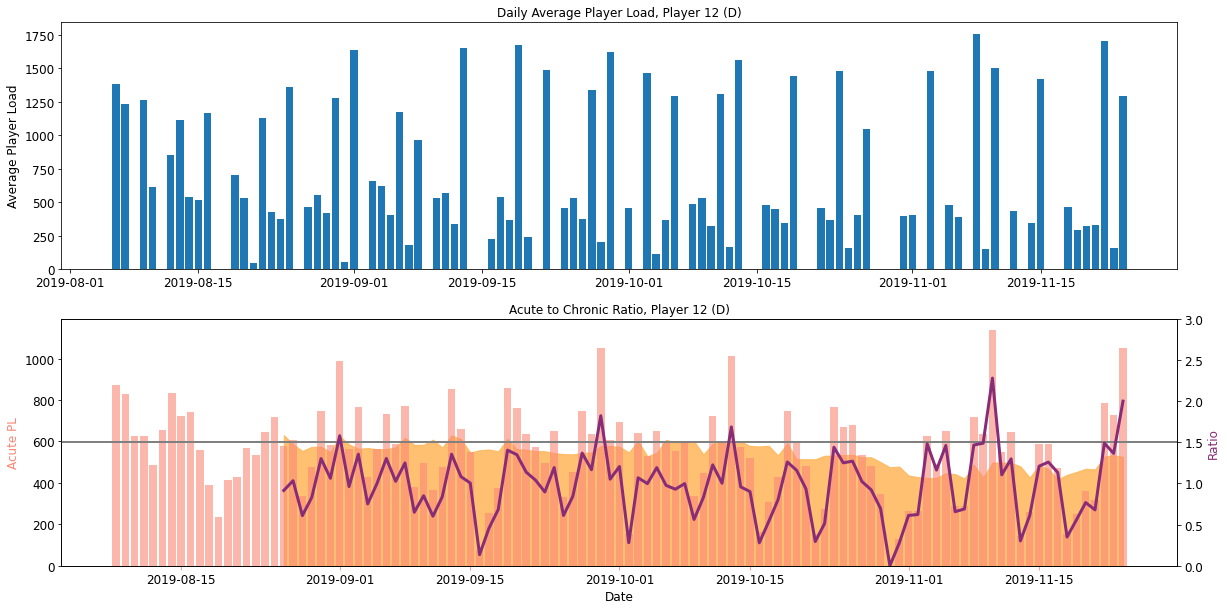

In [29]:
fig, axs = plt.subplots(2,figsize=(20, 10))

axs[0].bar(df_43.index, df_43["Total.Player.Load"])
#axs[0].set_xlabel("Date", fontsize=12)
axs[0].tick_params(axis='x', labelsize=12,)
axs[0].set_ylabel('Average Player Load', fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].set_title("Daily Average Player Load, Player 12 (D)", fontsize=12)

color='#FA8775'
axs[1].set_xlabel("Date", fontsize=12)
axs[1].tick_params(axis='x', labelsize=12, color=color)
axs[1].set_ylabel('Acute PL', color=color, fontsize=12)
axs[1].bar(df_43.index, df_43["Acute_PL"], color=color, alpha=0.6)
axs[1].tick_params(axis='y', labelsize=12)
color='#FFB14E'
axs[1].fill_between(df_43.index, df_43["Chronic_PL"], color=color, alpha=0.8)
axs[1] = plt.gca()
axs[1].set_title("Acute to Chronic Ratio, Player 12 (D)", fontsize=12)
axs1 = axs[1].twinx()  # instantiate a second axes that shares the same x-axis

color='#882C78'
axs1.set_ylabel('Ratio', fontsize=12, color=color)  # we already handled the x-label with ax1
axs1.plot(df_43.index, df_43["Acute:Chronic"], color=color, linewidth=3.0)
axs1.tick_params(axis='y', labelsize=12)
axs1 = plt.gca()

# To see how the acute to chronic workload ratio drops over the first 28 days, 
# comment out this line by adding a '#' in front of the line
axs1.set_ylim([0,3.0])

axs1.axhline(y=1.5,c="gray",linewidth=2,zorder=0)

### Step 8

In [32]:
df_all = session_df.groupby("Date").sum()
df_all = df_all.resample('D').sum()
df_all = df_all.fillna(0)

df_all["Acute_PL"] = (df_all.loc[:,"Total.Player.Load"].rolling('3D', 3).sum())/3
df_all["Chronic_PL"] = (df_all.loc[:,"Total.Player.Load"].rolling('21D', 21).sum())/21
df_all["Acute:Chronic"] = df_all.loc[:,"Acute_PL"]/df_all.loc[:,"Chronic_PL"]
df_all.head(30)

,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,
2019-08-06,21457.62648,578.47427,9810,1464,7896.95444,2718.800956,NaN,NaN,NaN
2019-08-07,21576.70582,320.09410,9141,1221,6727.04942,3960.461380,NaN,NaN,NaN
2019-08-08,0.00000,0.00000,0,0,0.00000,0.000000,14344.777433,NaN,NaN
2019-08-09,19715.55092,255.97996,7105,1023,5253.16905,3173.360914,13764.085580,NaN,NaN
2019-08-10,8707.56628,113.13464,3862,693,2801.49209,1653.143806,9474.372400,NaN,NaN
2019-08-11,0.00000,0.00000,0,0,0.00000,0.000000,9474.372400,NaN,NaN
2019-08-12,13495.42490,135.41093,3485,411,2492.89425,1986.196151,7400.997060,NaN,NaN
2019-08-13,16179.74976,196.51043,7326,327,5058.30292,3311.968716,9891.724887,NaN,NaN
2019-08-14,9114.80171,112.96797,3549,303,2456.94682,1613.696645,12929.992123,NaN,NaN


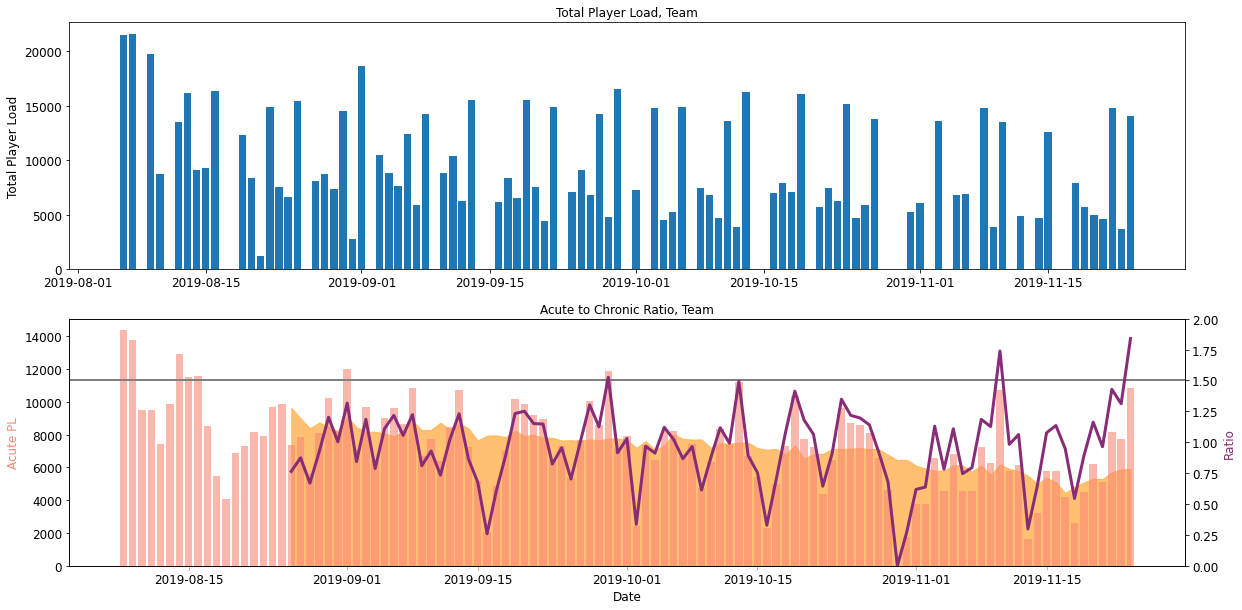

In [33]:
fig, axs = plt.subplots(2,figsize=(20, 10))

axs[0].bar(df_all.index, df_all["Total.Player.Load"])
#axs[0].set_xlabel("Date", fontsize=12)
axs[0].tick_params(axis='x', labelsize=12)
axs[0].set_ylabel('Total Player Load', fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].set_title("Total Player Load, Team", fontsize=12)

color='#FA8775'
axs[1].set_xlabel("Date", fontsize=12)
axs[1].tick_params(axis='x', labelsize=12, color=color)
axs[1].set_ylabel('Acute PL', color=color, fontsize=12)
axs[1].bar(df_all.index, df_all["Acute_PL"], color=color, alpha=0.6)
axs[1].tick_params(axis='y', labelsize=12)

color='#FFB14E'
axs[1].fill_between(df_all.index, df_all["Chronic_PL"], color=color, alpha=0.8)
axs[1] = plt.gca()
axs[1].set_title("Acute to Chronic Ratio, Team", fontsize=12)
axs1 = axs[1].twinx()  # instantiate a second axes that shares the same x-axis

color='#882C78'
axs1.set_ylabel('Ratio', fontsize=12, color=color)  # we already handled the x-label with ax1
axs1.plot(df_all.index, df_all["Acute:Chronic"], color=color, linewidth=3.0)
axs1.tick_params(axis='y', labelsize=12)
axs1 = plt.gca()

# To see how the acute to chronic workload ratio drops over the first 28 days, 
# comment out this line by adding a '#' in front of the line
axs1.set_ylim([0,2.0])

axs1.axhline(y=1.5,c="gray",linewidth=2,zorder=0)

### Step 9

In [34]:
df_all[df_all["Acute:Chronic"] > 1.5 ]

,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,
2019-09-29,16510.51763,160.57588,3930,503,2935.97880,1955.542138,11844.918730,7760.283862,1.526351
2019-11-10,13527.89556,143.96280,2777,373,2265.97600,1552.761600,10746.631557,6181.182352,1.738605
2019-11-24,14027.23956,141.80282,1751,0,1432.14411,1558.522129,10856.481493,5902.242050,1.839383


### Step 10

In [35]:
df_all['Session.Duration'].min()

0.0

In [36]:
df_all['Session.Duration'][df_all['Session.Duration'] > 0].min()

379.61618922878023

In [38]:
df_all[df_all['Session.Duration']==379.61618922878023]

,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,
2019-08-21,1223.74407,33.08703,1815,542,1453.59259,379.616189,7290.63043,NaN,NaN
